<a href="https://colab.research.google.com/github/ByvatovS/ML_Task/blob/main/Vehicles_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#!unzip VehiclesDetection.zip

In [9]:
!pip install ultralytics

In [26]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from ultralytics import YOLO
import optuna
import pandas as pd

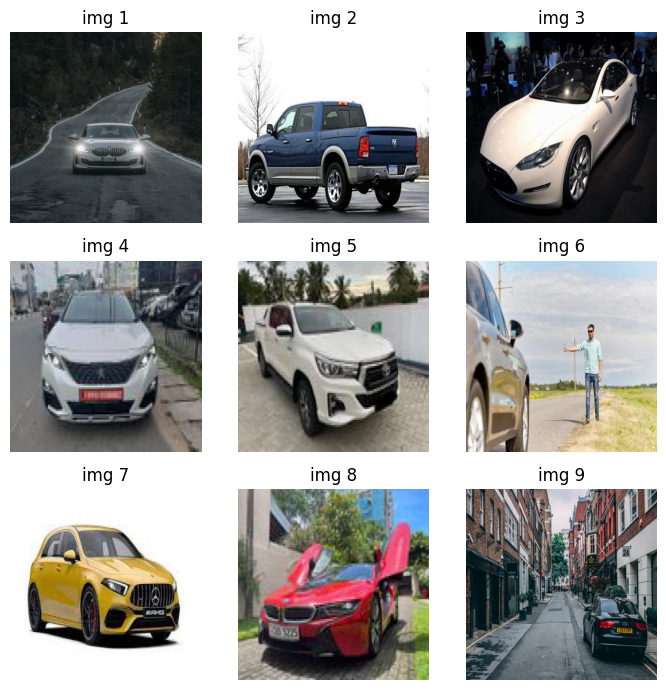

In [12]:
num_img = 9
img_dir = './train/images'
img_files = os.listdir(img_dir)

rand_img = random.sample(img_files , num_img)

fig, axs = plt.subplots(3, 3, figsize=(7,7))
for i in range(num_img):
  img = rand_img[i]
  ax = axs[i // 3 , i % 3]
  ax.imshow(plt.imread(os.path.join(img_dir, img)))
  ax.set_title(f"img {i + 1}")
  ax.axis('off')
plt.tight_layout()
plt.show()

In [13]:
img = cv2.imread('/content/train/images/00002_jpg.rf.34d3b5e07736565de587414fd11151e7.jpg')
img.shape

(416, 416, 3)

In [15]:
model = YOLO('yolov8n.pt')
result_model = model.train(data="./data.yaml",epochs = 30, batch = -1, optimizer = 'auto')

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=./data.yaml, epochs=30, time=None, patience=100, batch=-1, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width

train: Scanning /content/train/labels.cache... 633 images, 0 backgrounds, 0 corrupt: 100%|██████████| 633/633 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 62, len(boxes) = 919. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
AutoBatch: Computing optimal batch size for imgsz=640 at 60.0% CUDA memory utilization.
AutoBatch:  ⚠️ intended for CUDA devices, using default batch-size 16



train: Scanning /content/train/labels.cache... 633 images, 0 backgrounds, 0 corrupt: 100%|██████████| 633/633 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 62, len(boxes) = 919. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      30/30         0G     0.6252     0.5305      1.129         19        640: 100%|██████████| 40/40 [09:42<00:00, 14.56s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:54<00:00,  9.04s/it]

                   all        165        228      0.657      0.784      0.805      0.625



30 epochs completed in 5.337 hours.
Optimizer stripped from runs/detect/train6/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train6/weights/best.pt, 6.2MB

Validating runs/detect/train6/weights/best.pt...
Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:48<00:00,  8.05s/it]


                   all        165        228      0.656      0.784      0.805      0.625
                   car        129        151      0.916       0.96      0.969      0.803
                person         38         73      0.656       0.89      0.834      0.536
                 truck          2          4      0.397        0.5      0.611      0.537
Speed: 4.8ms preprocess, 273.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/train6


In [19]:
def display_image(image_file):

    image_path = os.path.join('./runs/detect/train6', image_file)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10), dpi=120)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

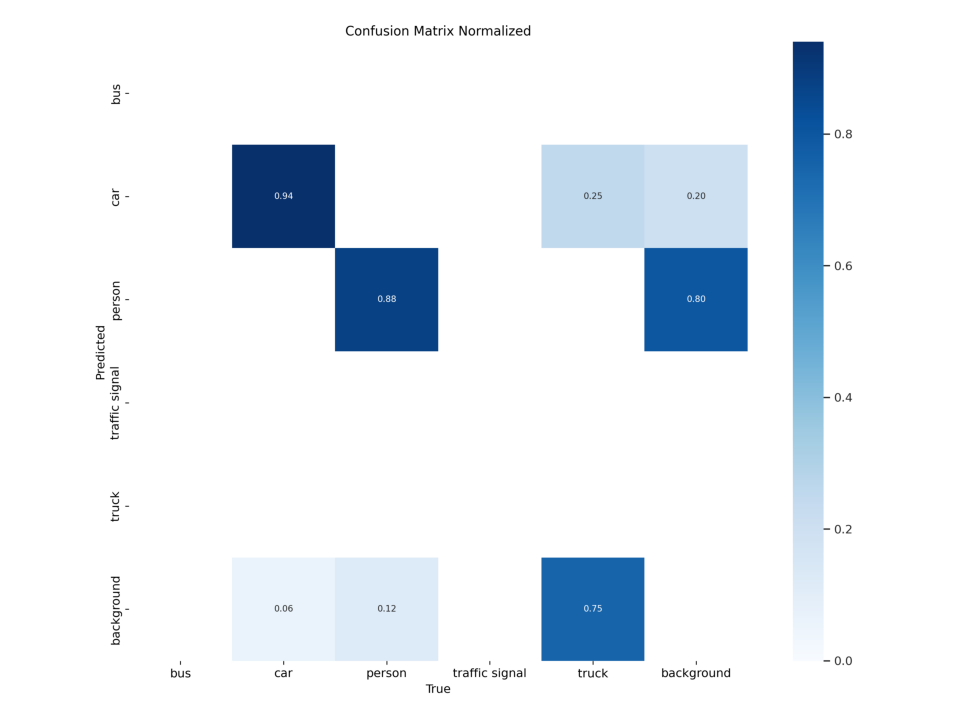

In [20]:
display_image('confusion_matrix_normalized.png')

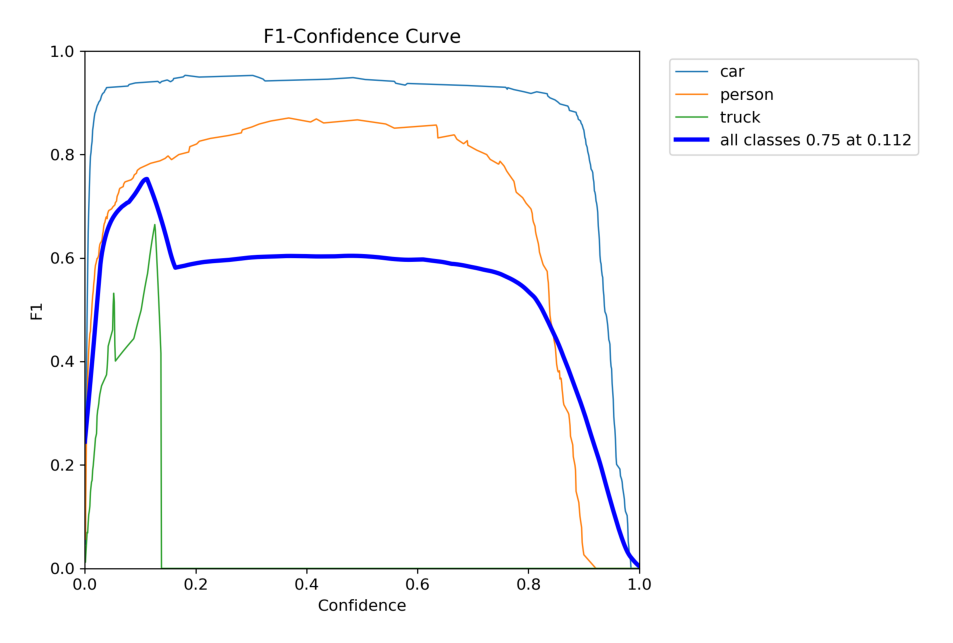

In [21]:
display_image('F1_curve.png')

The graph shows that with a confidence of 0.112, the model has balanced precision and recall quite effectively.

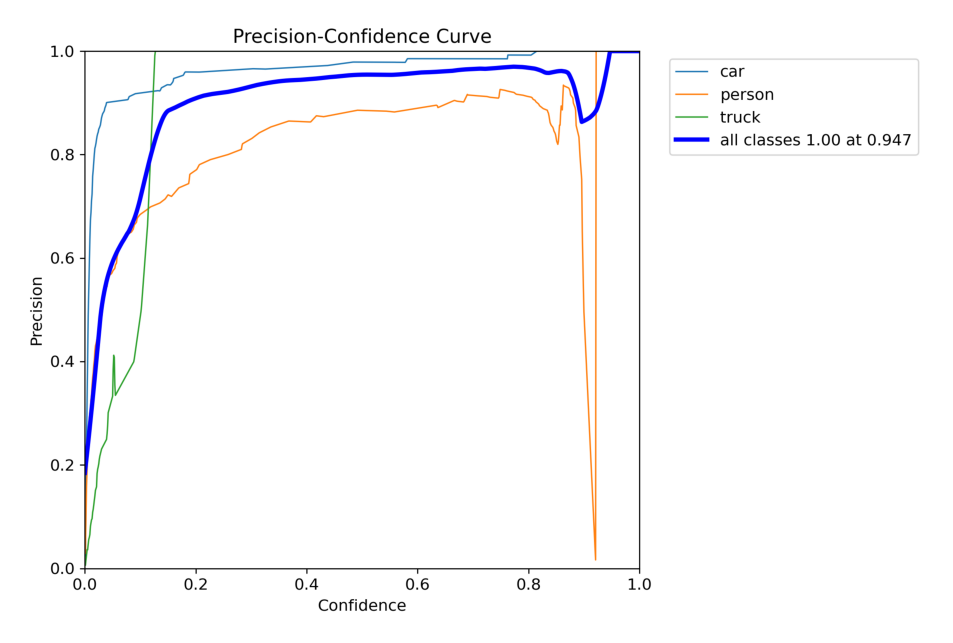

In [22]:
display_image('P_curve.png')

With confidence from 0.12 to 0.88, precision shows acceptable scores.

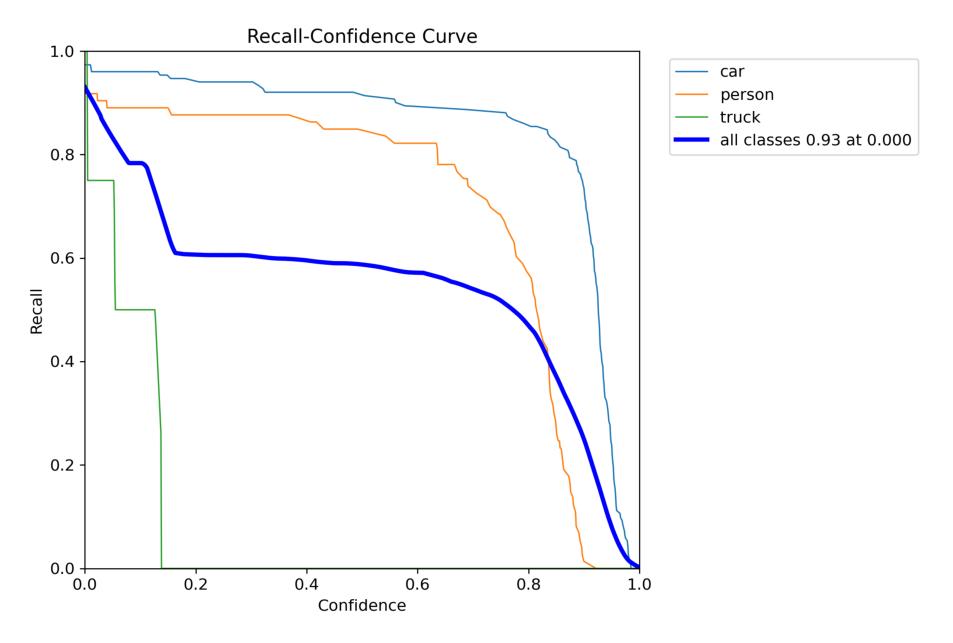

In [23]:
display_image('R_curve.png')

With a confidence of 0.1 to 0.15, the model demonstrates fairly good recall scores.

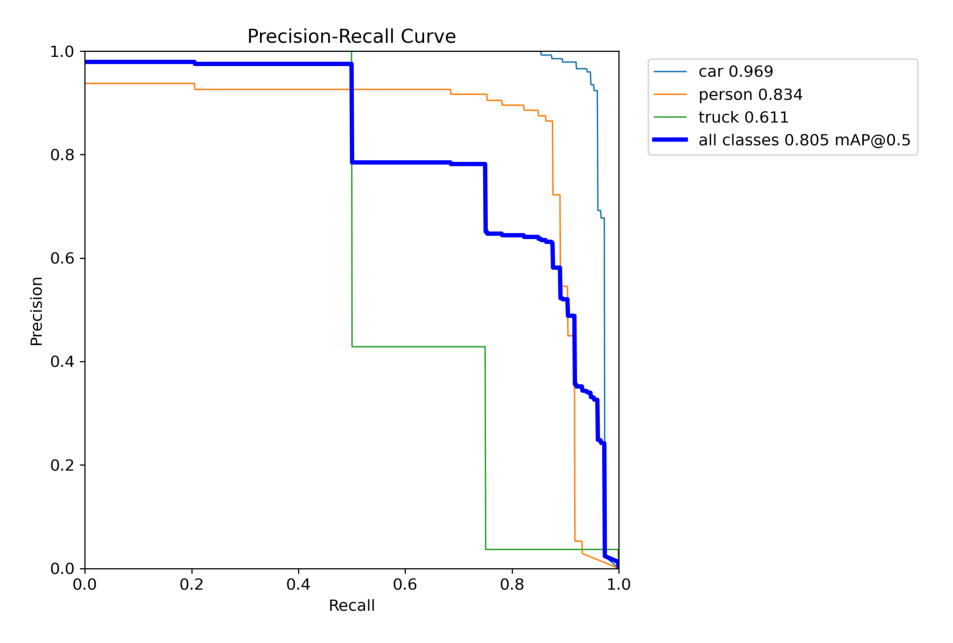

In [24]:
display_image('PR_curve.png')

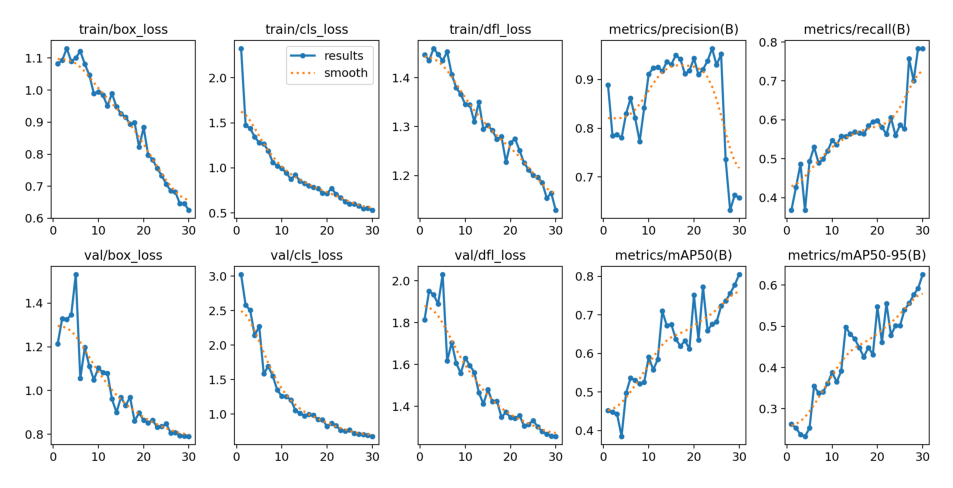

In [25]:
display_image('results.png')

In [27]:
result_model = pd.read_csv('./runs/detect/train6/results.csv')
result_model.tail(10)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
20,21,13584.3,0.79761,0.77411,1.27512,0.90995,0.58112,0.63493,0.46091,0.85244,0.86820,1.34209,0.000378,0.000378,0.000378
21,22,14205.3,0.78262,0.70701,1.25096,0.92106,0.56255,0.77301,0.55533,0.86325,0.83146,1.35515,0.000341,0.000341,0.000341
22,23,14845.8,0.75601,0.67084,1.22592,0.93819,0.60533,0.65911,0.47818,0.83173,0.76470,1.30548,0.000304,0.000304,0.000304
23,24,15478.0,0.73298,0.62705,1.21179,0.96407,0.56003,0.67610,0.50194,0.83559,0.75052,1.31395,0.000268,0.000268,0.000268
24,25,16121.2,0.70677,0.60181,1.20041,0.92998,0.58643,0.68162,0.50174,0.84755,0.76767,1.33208,0.000231,0.000231,0.000231
25,26,16746.8,0.68540,0.60144,1.19662,0.95229,0.57681,0.72282,0.53982,0.80487,0.71709,1.30240,0.000194,0.000194,0.000194
26,27,17351.0,0.68245,0.57959,1.18579,0.73565,0.75717,0.73609,0.55555,0.80695,0.70744,1.27913,0.000158,0.000158,0.000158
27,28,17962.3,0.64601,0.54842,1.15411,0.63140,0.70048,0.75549,0.57624,0.79283,0.70345,1.26727,0.000121,0.000121,0.000121
28,29,18575.3,0.64564,0.55129,1.16398,0.66268,0.78356,0.77776,0.59190,0.79071,0.68863,1.25735,0.000084,0.000084,0.000084
29,30,19212.7,0.62515,0.53051,1.12904,0.65684,0.78356,0.80471,0.62547,0.79015,0.67612,1.25620,0.000048,0.000048,0.000048


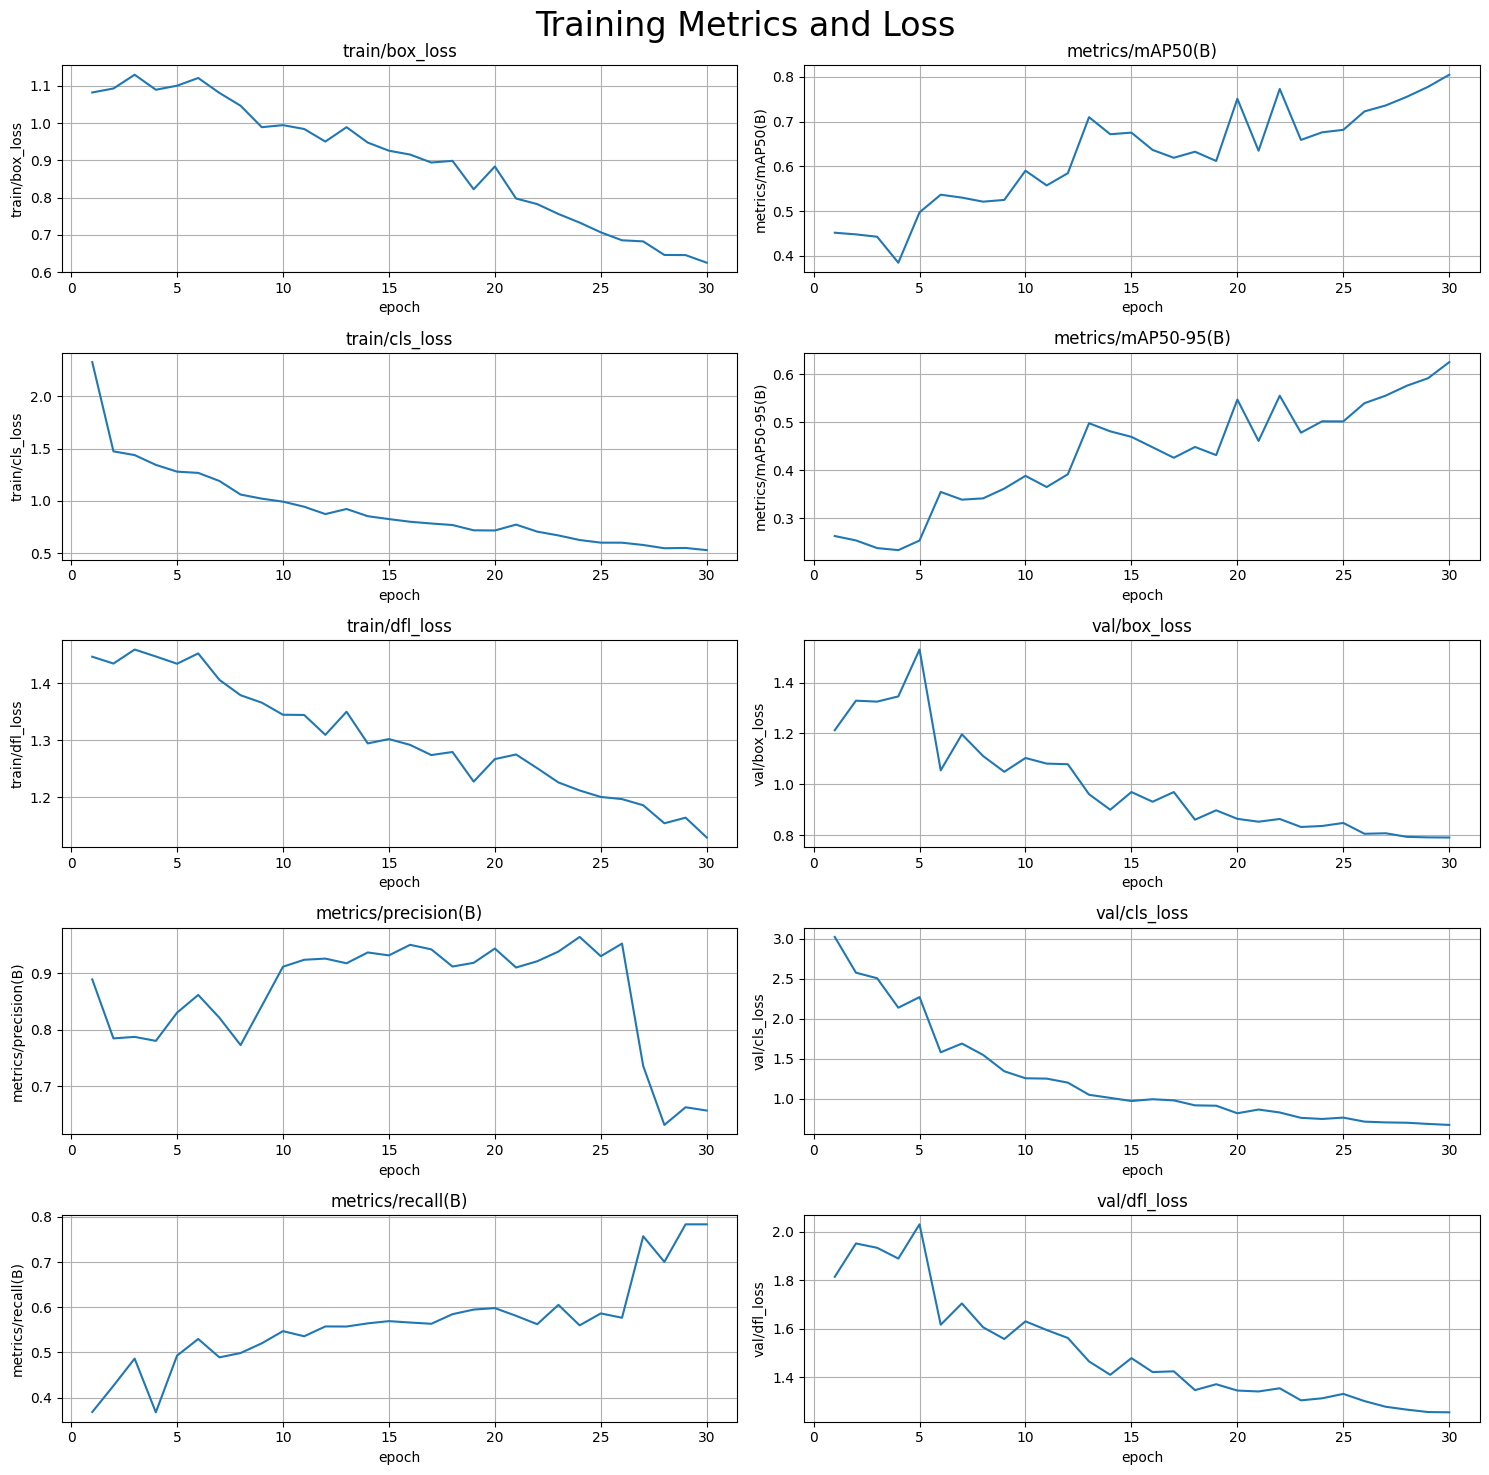

In [34]:
result_model.columns = result_model.columns.str.strip()

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))
titles = ['train/box_loss' , 'train/cls_loss' , 'train/dfl_loss',
          'metrics/precision(B)', 'metrics/recall(B)' , 'metrics/mAP50(B)' , 'metrics/mAP50-95(B)',
          'val/box_loss' , 'val/cls_loss' ,'val/dfl_loss' ]

for i in range(10):
  sns.lineplot(x='epoch' , y=titles[i] , data=result_model , ax=axs[i % 5 , i // 5])
  axs[i % 5 , i // 5].set(title= titles[i])
  axs[i % 5 , i // 5].grid()


plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()


0: 640x640 1 car, 391.6ms
Speed: 4.9ms preprocess, 391.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 cars, 350.2ms
Speed: 4.5ms preprocess, 350.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 persons, 355.0ms
Speed: 4.2ms preprocess, 355.0ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 cars, 1 person, 352.2ms
Speed: 4.2ms preprocess, 352.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 car, 305.1ms
Speed: 4.9ms preprocess, 305.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 car, 229.1ms
Speed: 3.9ms preprocess, 229.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 car, 239.7ms
Speed: 5.0ms preprocess, 239.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 cars, 220.9ms
Speed: 4.1ms preprocess, 220.9ms inference, 1.1ms postprocess per image at shape 

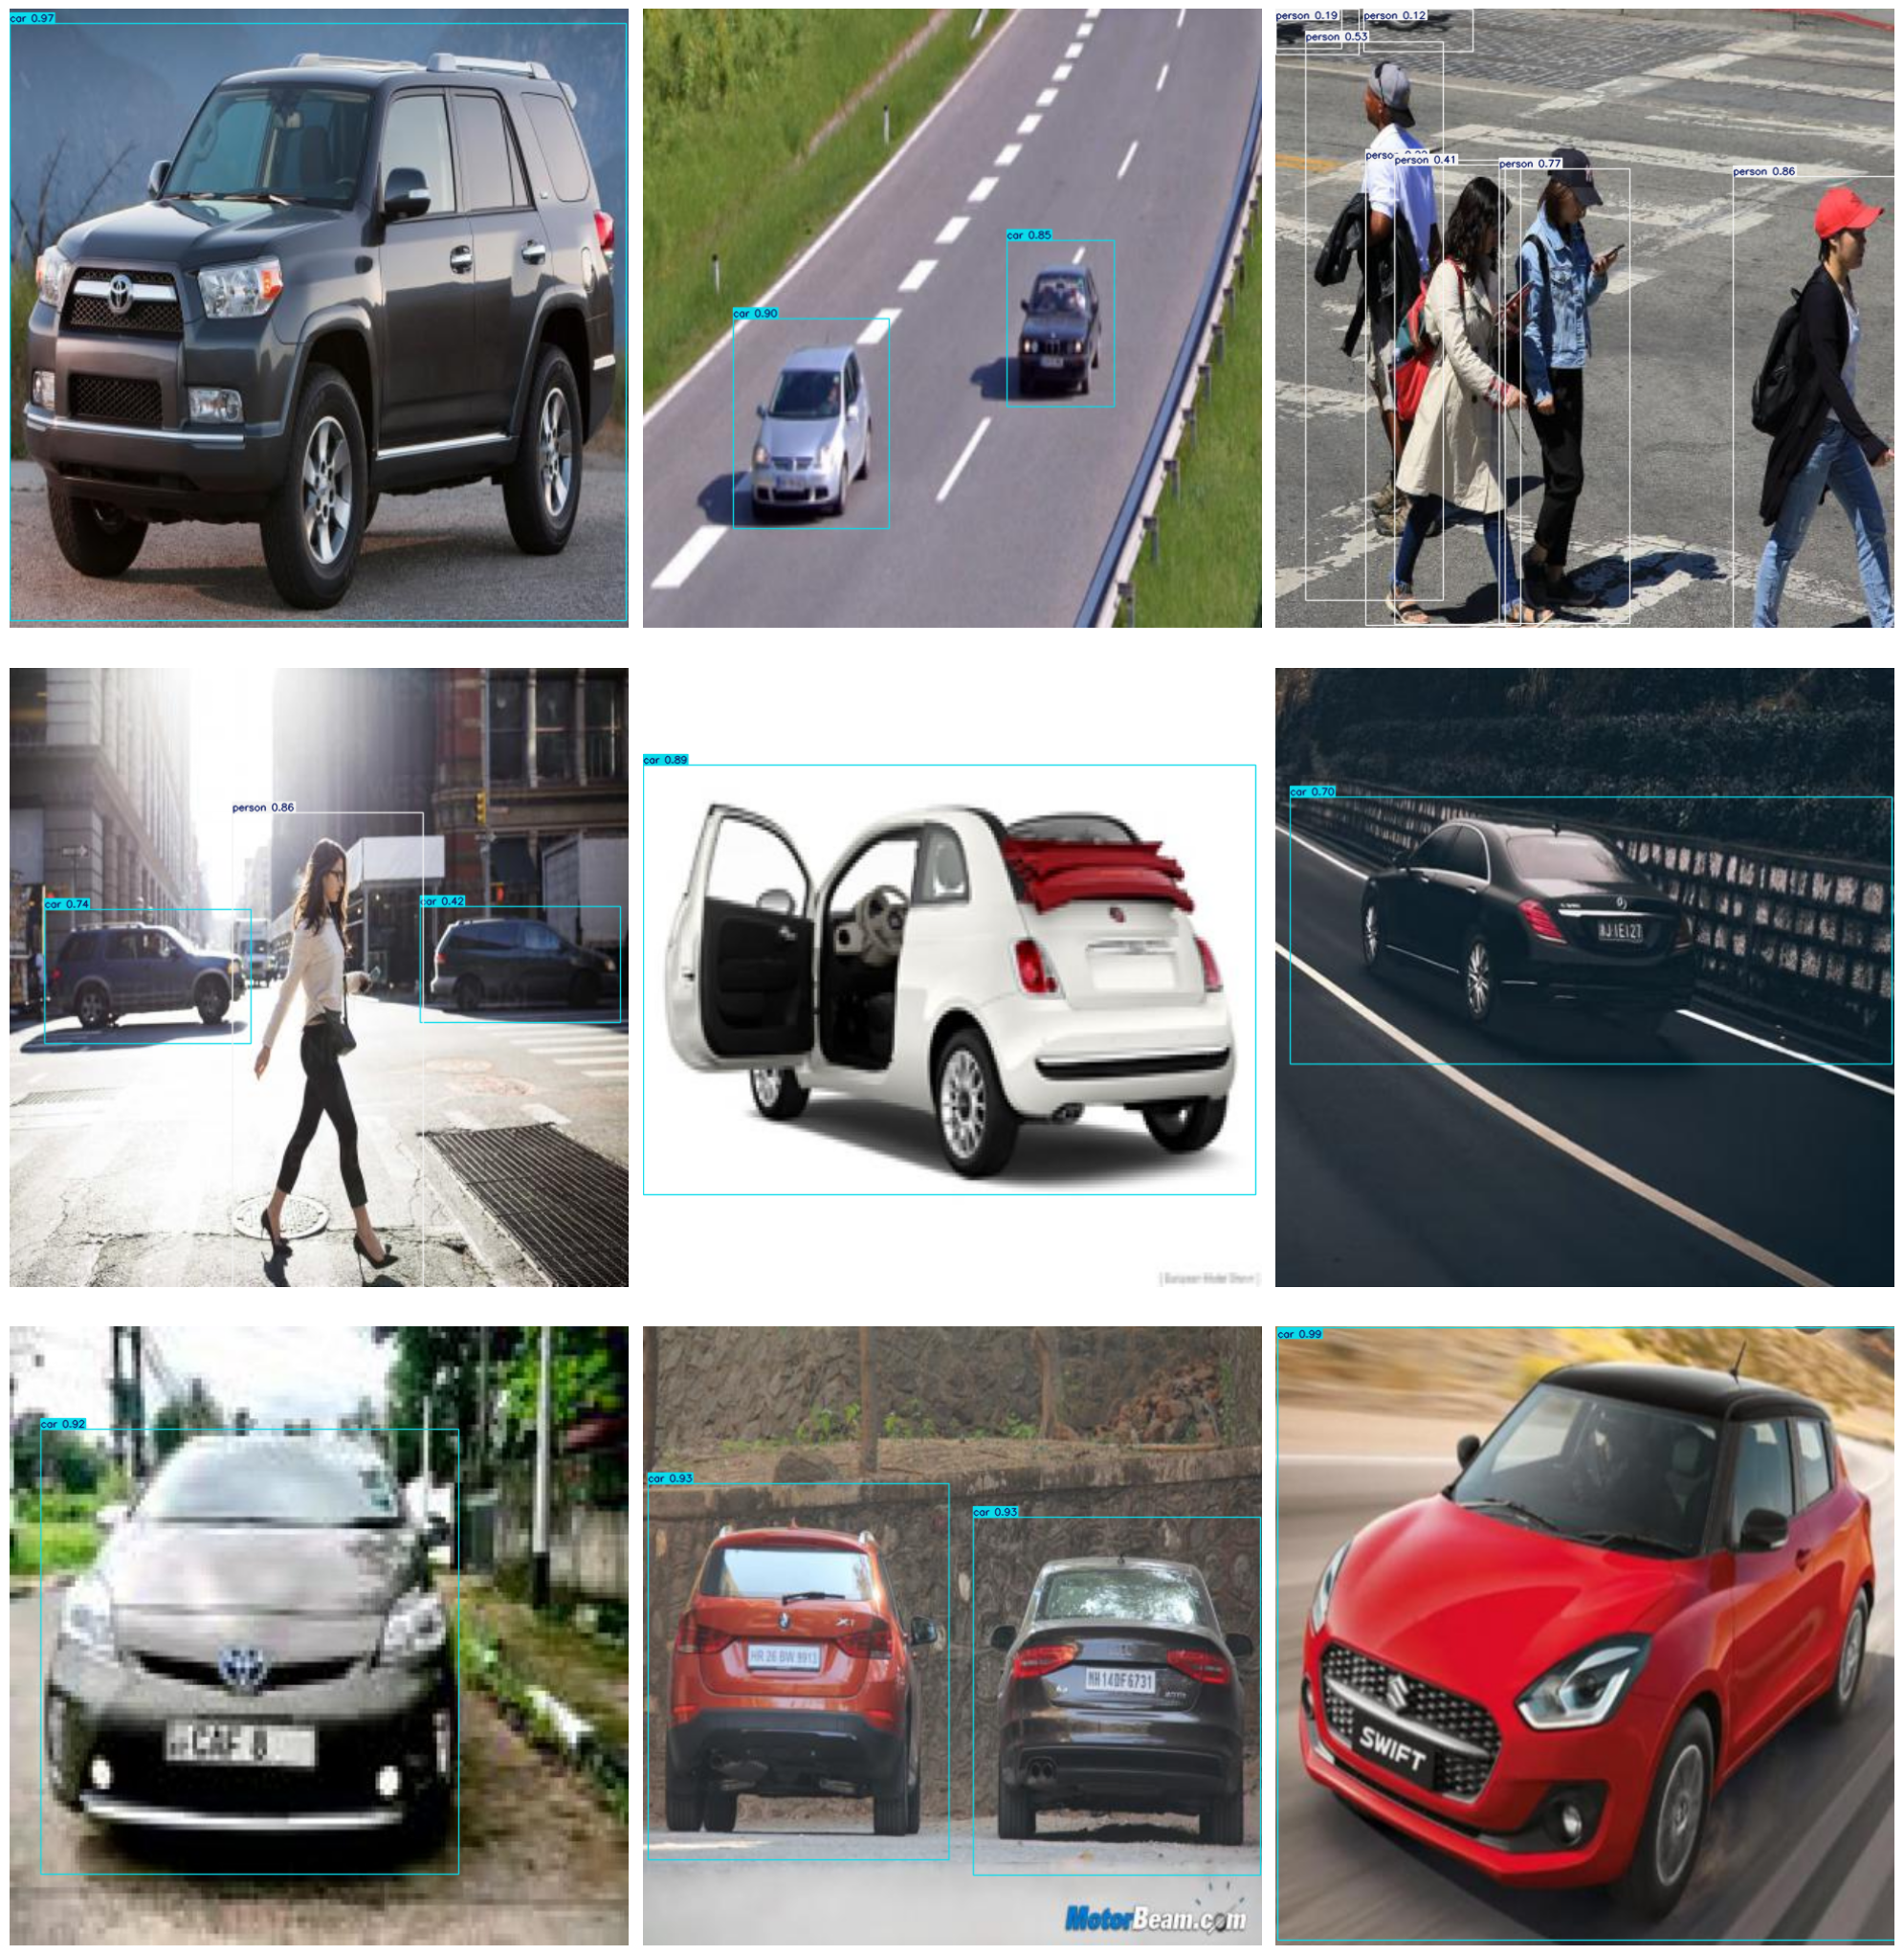

In [45]:
def resize_image(image, size=(640, 640)):
    return cv2.resize(image, size)

image_files = [file for file in os.listdir('./test/images') if file.endswith('.jpg')]

if len(image_files) > 0:
    num_images = len(image_files)
    step_size = max(1, num_images // 9)
    selected_images = [image_files[i] for i in range(0, num_images, step_size)]

    fig, axes = plt.subplots(3, 3, figsize=(20, 21))

    for i, ax in enumerate(axes.flatten()):
        if i < len(selected_images):
            image_path = os.path.join('./test/images', selected_images[i])
            image = cv2.imread(image_path)

            if image is not None:
                resized_image = resize_image(image, size=(640, 640))

                image_uint8 = (resized_image).astype(np.uint8)
                results = model.predict(source=image_uint8, imgsz=640, conf= 0.)

                annotated_image = results[0].plot(line_width=1)
                annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
                ax.imshow(annotated_image_rgb)
            else:
                print(f"Failed to load image {image_path}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()